In [1]:
!pip install librosa pandas numpy matplotlib seaborn scikit-learn

In [3]:
!pip install resampy

In [5]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

**Load Data** 

In [8]:
metadata = pd.read_csv("UrbanSound8K/metadata/UrbanSound8K.csv")

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


**Check Class Balance**

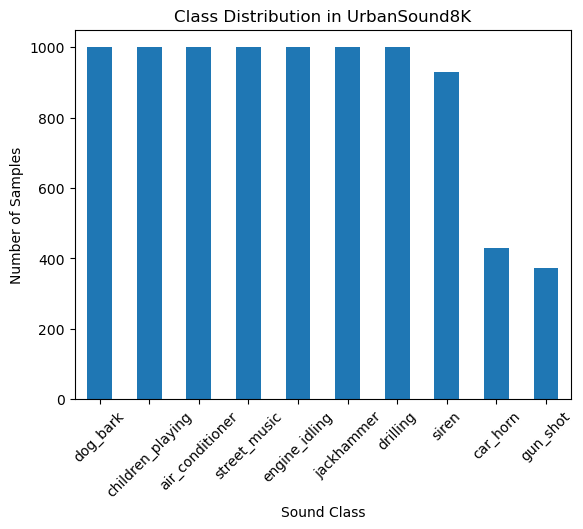

In [38]:
class_counts = metadata["class"].value_counts()

class_counts.plot(kind="bar")

plt.title("Class Distribution in UrbanSound8K")
plt.xlabel("Sound Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()

**Feature Extraction Function**

Extract:
- MFCCs (Mel-Frequency Cepstral Coefficients) - captures how humans percieve sound. Convert raw audio into a compact numerical representation that captures the important characteristics of sound. Represent this audio using 40 compressed frequency-shape coefficients.
- then average across time

In [11]:
def extract_features(file_path):
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=40
    )

    mfccs_scaled = np.mean(mfccs.T, axis=0)

    return mfccs_scaled

**Extract Features from All Audio Files**

In [14]:
features = []

for index, row in metadata.iterrows():

    file_name = os.path.join(
        os.path.abspath("UrbanSound8K/audio"),
        f"fold{row['fold']}",
        row['slice_file_name']
    )

    class_label = row["class"]

    data = extract_features(file_name)

    features.append([data, class_label])

print("Finished feature extraction")

/opt/anaconda3/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Finished feature extraction


**Create DataFrame**

In [17]:
features_df = pd.DataFrame(features, columns=['feature', 'class'])

features_df.head()

,feature,class
0,"[-217.35526, 70.22338, -130.38527, -53.282898,...",dog_bark
1,"[-424.09818, 109.34076, -52.919525, 60.86475, ...",children_playing
2,"[-458.79114, 121.38419, -46.520653, 52.00812, ...",children_playing
3,"[-413.89984, 101.66371, -35.42945, 53.036358, ...",children_playing
4,"[-446.60352, 113.68541, -52.402218, 60.302044,...",children_playing


**Prepare Training Data**

In [20]:
X = np.array(features_df['feature'].tolist())
y = np.array(features_df['class'].tolist())

**Train/Test Split**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Train Random Forest Model**

In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Make Predictions**

In [29]:
y_pred = model.predict(X_test)

**Evaluate Model**

In [34]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.90


In [42]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average="macro")
print(f1)

0.9001747779399351


**Vizualize of Spectogram**

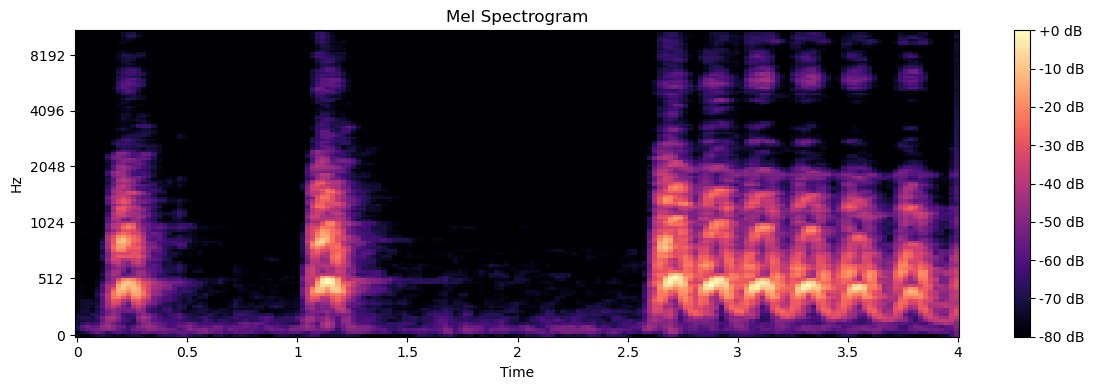

In [45]:
sample_file = "UrbanSound8K/audio/fold1/101415-3-0-2.wav"

audio, sr = librosa.load(sample_file)

plt.figure(figsize=(12,4))

spectrogram = librosa.feature.melspectrogram(
    y=audio,
    sr=sr
)

spectrogram_db = librosa.power_to_db(
    spectrogram,
    ref=np.max
)

librosa.display.specshow(
    spectrogram_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')

plt.title('Mel Spectrogram')

plt.tight_layout()

plt.show()

**Feature Inmportance**

In [52]:
model.feature_importances_

array([0.05116916, 0.0528439 , 0.03615269, 0.06588872, 0.02667692,
       0.0400794 , 0.03833079, 0.03750729, 0.02790963, 0.0211146 ,
       0.02570949, 0.02237857, 0.02609072, 0.02412246, 0.02071703,
       0.02132945, 0.02440224, 0.02116936, 0.01814588, 0.02118902,
       0.01612617, 0.01936775, 0.01805081, 0.01634847, 0.01921427,
       0.02081001, 0.01841504, 0.01867383, 0.01978777, 0.01623181,
       0.01844504, 0.01766335, 0.02006243, 0.01626097, 0.01953783,
       0.01890804, 0.02120602, 0.02508829, 0.01658914, 0.02028565])

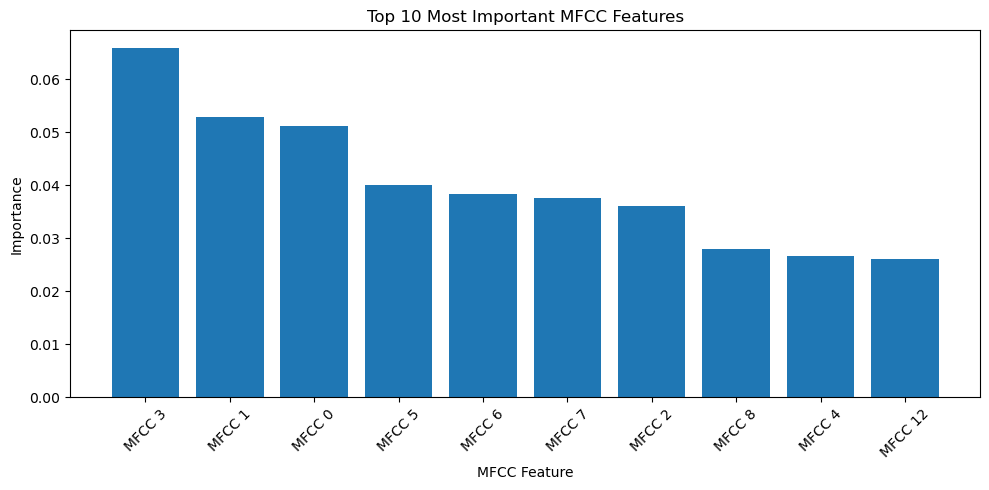

In [54]:
importances = model.feature_importances_
feature_names = np.array([f"MFCC {i}" for i in range(len(importances))])

# Sort
indices = np.argsort(importances)[::-1]

top_n = 10

plt.figure(figsize=(10,5))

plt.bar(feature_names[indices][:top_n],
        importances[indices][:top_n])

plt.title("Top 10 Most Important MFCC Features")
plt.xlabel("MFCC Feature")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()